In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('notebook')
from IPython.display import display, Audio
import soundfile as sf
import librosa

# Código: Convolución 

## Convolución entre señales sencillas

Convolución entre dos pulsos cuadrados con la función `numpy.convolve`. Si las señales a convolucionar tienen largos $N$ y $M$, el resultado de la convolución tendrá largo $N+M-1$.

Largo de f:  2000
Largo de g:  2000
Largo de y:  3999


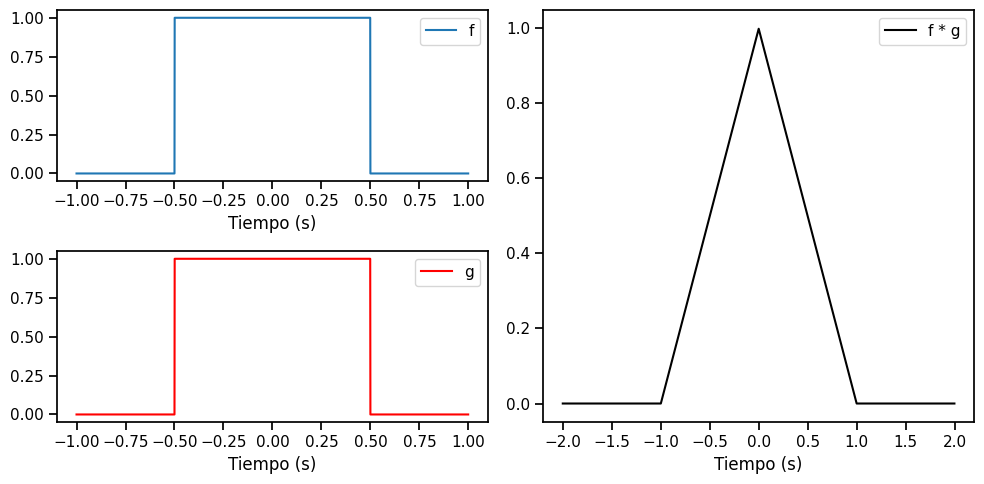

In [2]:
sr = 1000
dur = 2.0
t = np.arange(int(dur*sr))/sr - 1

# Creamos dos señales f y g con forma de pulso cuadrado
f = np.zeros(t.shape)
mask = ( t>-0.5) & ( t<0.5 )
f[mask] = 1

g = f

plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.plot(t,f,label='f');
plt.xlabel('Tiempo (s)')
plt.legend();
plt.subplot(2,2,3)
plt.plot(t,g,'r',label='g');
plt.xlabel('Tiempo (s)')
plt.legend();

# Usamos la funcion convolve
y = np.convolve(f,g)/sr

print("Largo de f: ", len(f))
print("Largo de g: ", len(g))
print("Largo de y: ", len(y))

plt.subplot(1,2,2)
t = np.arange(len(y))/sr
plt.plot(t-t.mean(),y,'k',label='f * g')
plt.xlabel('Tiempo (s)')
plt.legend()
plt.tight_layout()
plt.show()

Convolución entre impulsos y una señal arbitraria $h[n]$ como si fuera la respuesta al impulso de un sistema LTI:

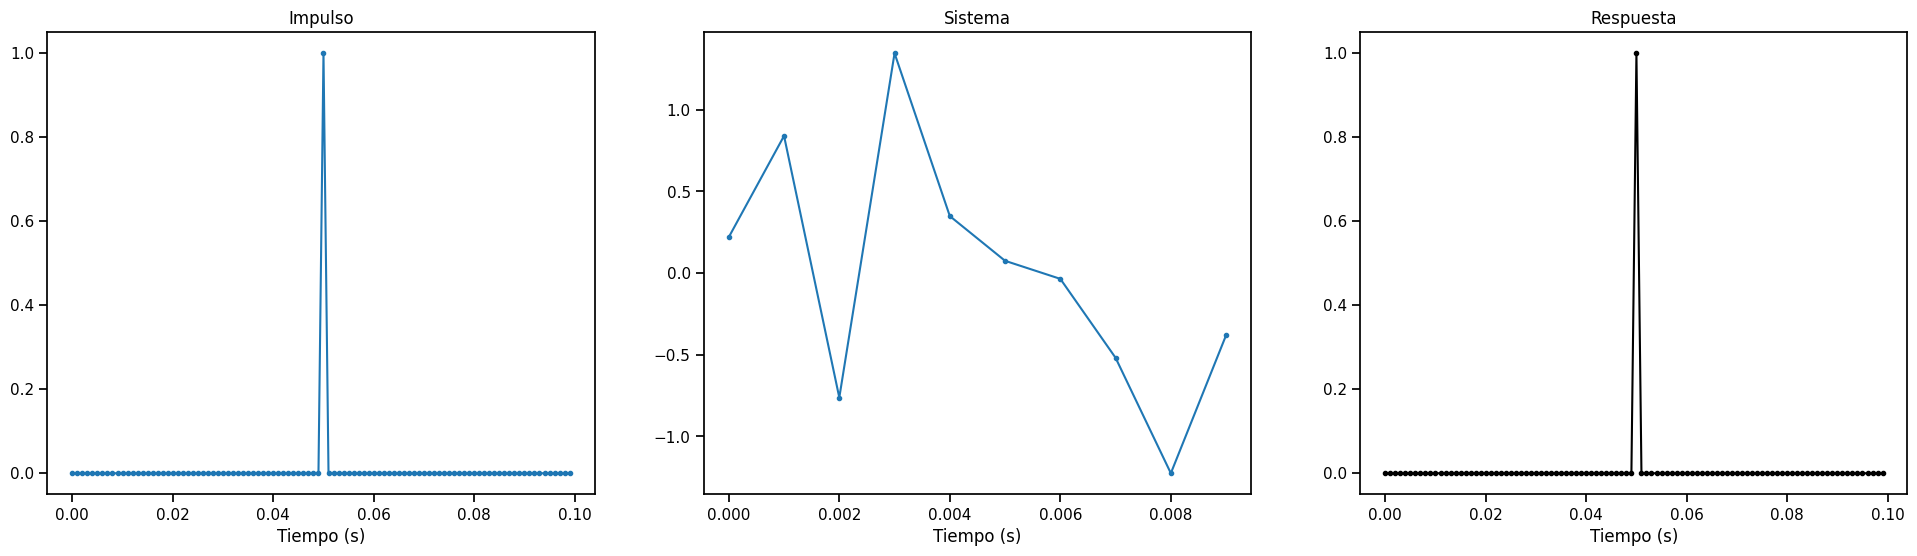

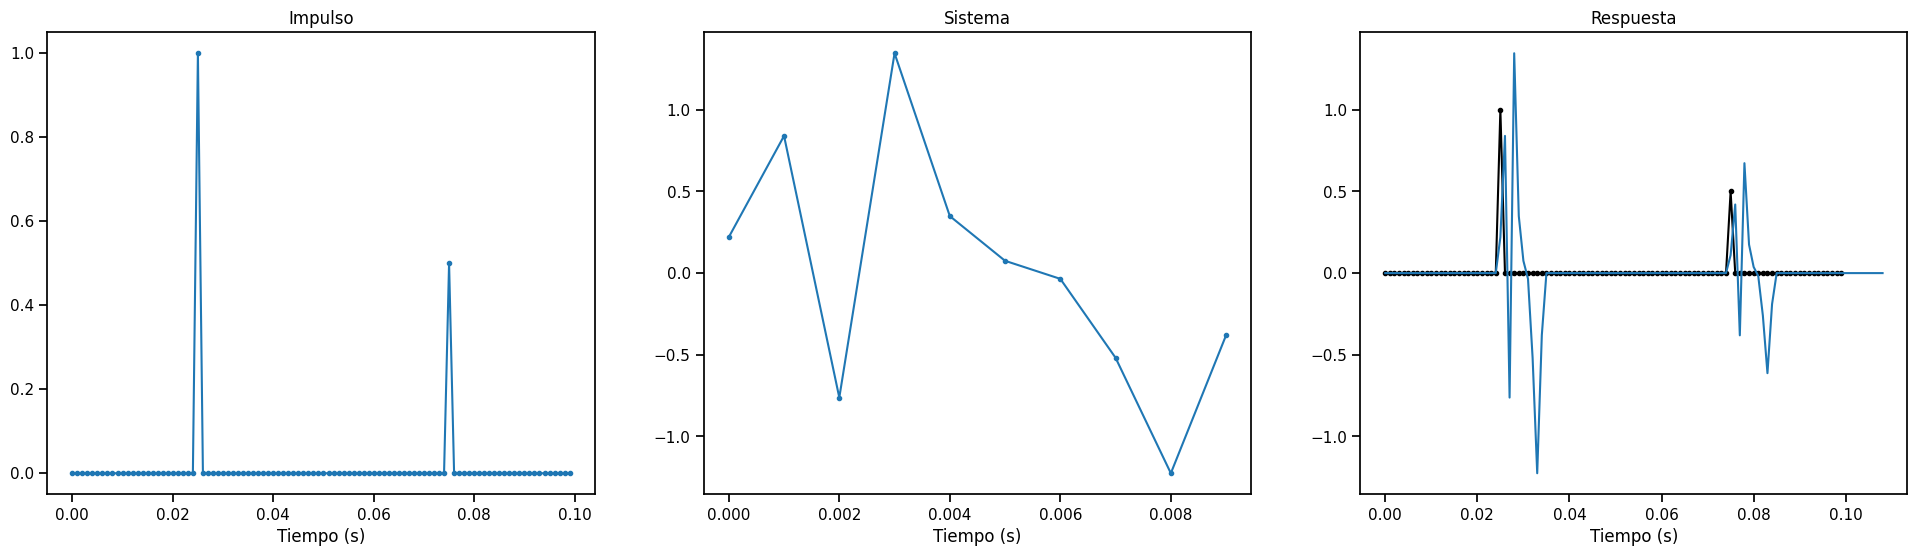

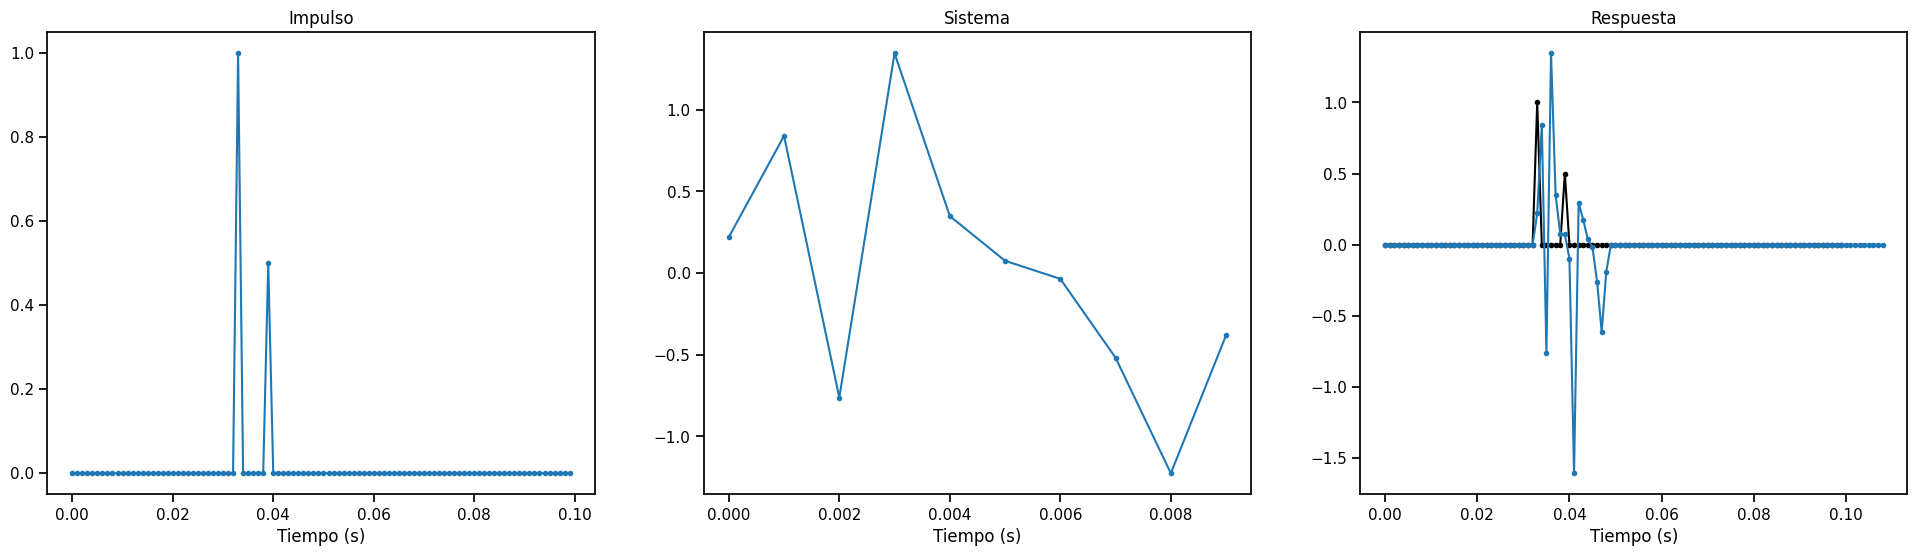

In [3]:
sr = 1000
dur = 0.1
t = np.arange(int(dur*sr))/sr

impulso = np.zeros(t.shape)
impulso[len(t)//2] = 1

# Sistema aleatorio desconocido
sistema = np.random.randn(10)
t_s = np.arange(len(sistema))/sr

y = np.convolve(impulso, sistema)
t_y = np.arange(len(y))/sr

plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.plot(t, impulso,'.-');
plt.xlabel("Tiempo (s)")
plt.title("Impulso")

plt.subplot(1,3,2)
plt.plot(t_s, sistema,'.-')
plt.xlabel("Tiempo (s)")
plt.title("Sistema")

plt.subplot(1,3,3)
plt.plot(t, impulso,'.-k')
plt.plot(t_y = y)
plt.xlabel("Tiempo (s)")
plt.title("Respuesta");

sr = 1000
dur = 0.1
t = np.arange(int(dur*sr))/sr

impulso = np.zeros(t.shape)
impulso[len(t)//4] = 1
impulso[len(t)//4*3] = 0.5

y = np.convolve(impulso,sistema,'full')

plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.plot(t, impulso,'.-');
plt.xlabel("Tiempo (s)")
plt.title("Impulso")

plt.subplot(1,3,2)
plt.plot(t_s, sistema,'.-')
plt.xlabel("Tiempo (s)")
plt.title("Sistema")

plt.subplot(1,3,3)
plt.plot(t, impulso,'.-k')
plt.plot(t_y, y)
plt.xlabel("Tiempo (s)")
plt.title("Respuesta");


sr = 1000
dur = 0.1
t = np.arange(int(dur*sr))/sr

impulso = np.zeros(t.shape)
impulso[len(t)//3] = 1
impulso[int(len(t)//3*1.2)] = 0.5

y = np.convolve(impulso,sistema,'full')

plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.plot(t, impulso,'.-');
plt.xlabel("Tiempo (s)")
plt.title("Impulso")

plt.subplot(1,3,2)
plt.plot(t_s, sistema,'.-')
plt.xlabel("Tiempo (s)")
plt.title("Sistema")

plt.subplot(1,3,3)
plt.plot(t, impulso,'.-k')
plt.plot(t_y, y,'.-')
plt.xlabel("Tiempo (s)")
plt.title("Respuesta");

plt.show()

## Convolución entre audio y respuestas al impulso: Auralización

La auralización es un procedimiento para simular la escucha dentro de un recinto sin tener que estar físicamente. El proceso consiste en convolucionar audios tomados en una cámara anecoica con una respuesta impulsiva (IR) que caracteriza el recinto.

En el siguiente ejemplo convolucionamos una señal de audio de una cantante con la respuesta al impulso de una sala para simular la reverberación de un espacio:

In [ ]:

# Cargamos audios
sr = 44100
s, sr = librosa.load('../../assets/singing.wav',sr=sr)
t_s = np.arange(len(s))/sr
ir, sr  = librosa.load('../../assets/ir_larga.wav',sr=sr)
t_ir = np.arange(len(ir))/sr

# Convolución
s_conv_ir = np.convolve(s, ir) # tarda más de 20 segundos en ejecutarse
t = np.arange(len(s_conv_ir))/sr

plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.plot(t_s, s)
plt.xlabel('Tiempo (s)')
plt.title('Audio')

plt.subplot(1,3,2)
plt.plot(t_ir, ir)
plt.xlabel('Tiempo (s)')
plt.title('Respuesta impulso');

plt.subplot(1,3,3)
plt.plot(t, s_conv_ir)
plt.xlabel('Tiempo (s)')
plt.title('Audio convolucionado')
plt.show()

display(Audio(s,rate=sr))
display(Audio(ir,rate=sr))
display(Audio(s_conv_ir,rate=sr))
plt.show()


##  Respuestas al impulso de recintos sintéticas

Podemos modelar respuesta impulso de recientos mediante métodos geométricos o métodos basados en la ecuación de onda para la propagación del sonido, modelado temporal, etc.

Un [modelo sencillo](https://ccrma.stanford.edu/~njb/research/icassp2020_ir_augmentation.pdf) consiste en considerar que una respuesta al impulso no es mas que una señal de ruido modulada en amplitud por una exponencial decreciente.

$$
	h(t) = A e^{\frac{-(t)}{\tau}}n(t)+\sigma n(t)
$$

En donde $A$ es la amplitud inicial, $\tau$ es la tasa de caída, $\sigma$ es el nivel del piso de ruido, y $n(t)$ es ruido Gaussiano de media cero y desvío estándar unitario.

Generemos un impulso siguiendo esta teoria. Experimentar con el efecto resultante de distintos valores de $\tau$

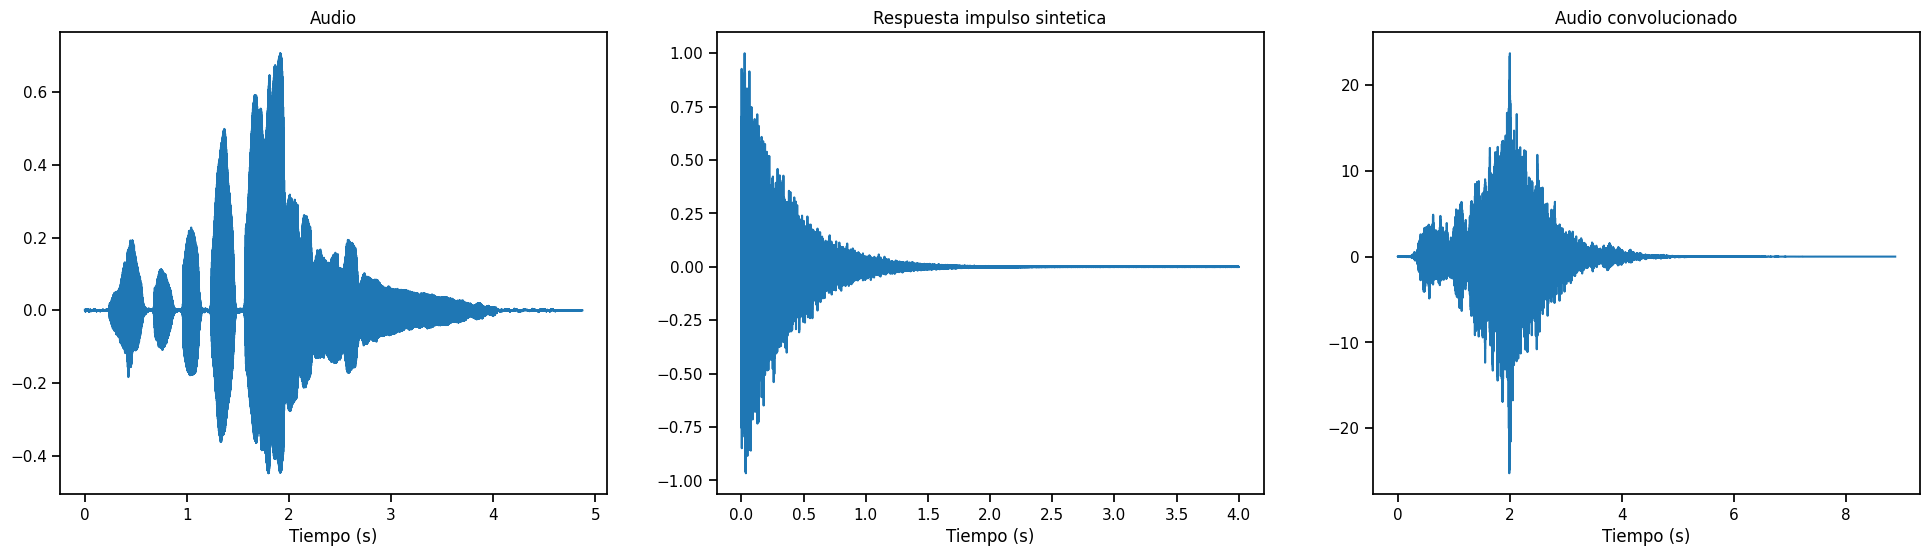

In [ ]:
sr = 44100
t_ir = np.arange(0,int(4*sr))/sr

# ruido
noise = np.random.normal(0,1,t_ir.size)

# envolvente
Am = 1
tau = 0.35
envelope = Am*np.exp(-t_ir/tau)

# modulación y piso de ruido
sigma = 0.001
ir_synth = (envelope * noise) + sigma*np.random.normal(0,1,t_ir.size)
ir_synth = ir_synth / np.max(np.abs(ir_synth))

s_conv_ir = np.convolve(s, ir_synth)
t = np.arange(len(s_conv_ir))/sr

plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.plot(t_s, s)
plt.xlabel('Tiempo (s)')
plt.title('Audio')

plt.subplot(1,3,2)
plt.plot(t_ir, ir_synth)
plt.xlabel('Tiempo (s)')
plt.title('Respuesta impulso sintetica');

plt.subplot(1,3,3)
plt.plot(t, s_conv_ir)
plt.xlabel('Tiempo (s)')
plt.title('Audio convolucionado')
plt.show()

display(Audio(s,rate=sr))
display(Audio(ir_synth,rate=sr))
display(Audio(s_conv_ir, rate=sr))
plt.show()

## Síntesis granular con convolución

Un grano de audio es una pequeña porción de audio que se repite muchas veces. Suele tener una envolvente suave y un tamaño de unos pocos milisegundos. Podemos superponer granos facilmente utilzando la convolución. Primero elijamos un grano

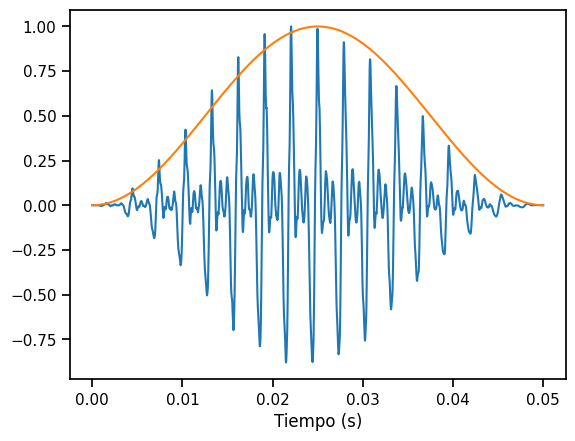

In [ ]:
sr = 44100
t1 = 0.5
t2 = t1 + 0.05

grano = s[int(t1*sr):int(t2*sr)]

env = (1-np.cos(2*np.pi*np.arange(len(grano))/len(grano)))*0.5
grano = grano*env
grano = grano/np.max(np.abs(grano))

t = np.arange(len(grano))/sr
plt.plot(t,grano)
plt.plot(t,env)
plt.xlabel("Tiempo (s)")

display(Audio(grano,rate=sr))
plt.show()

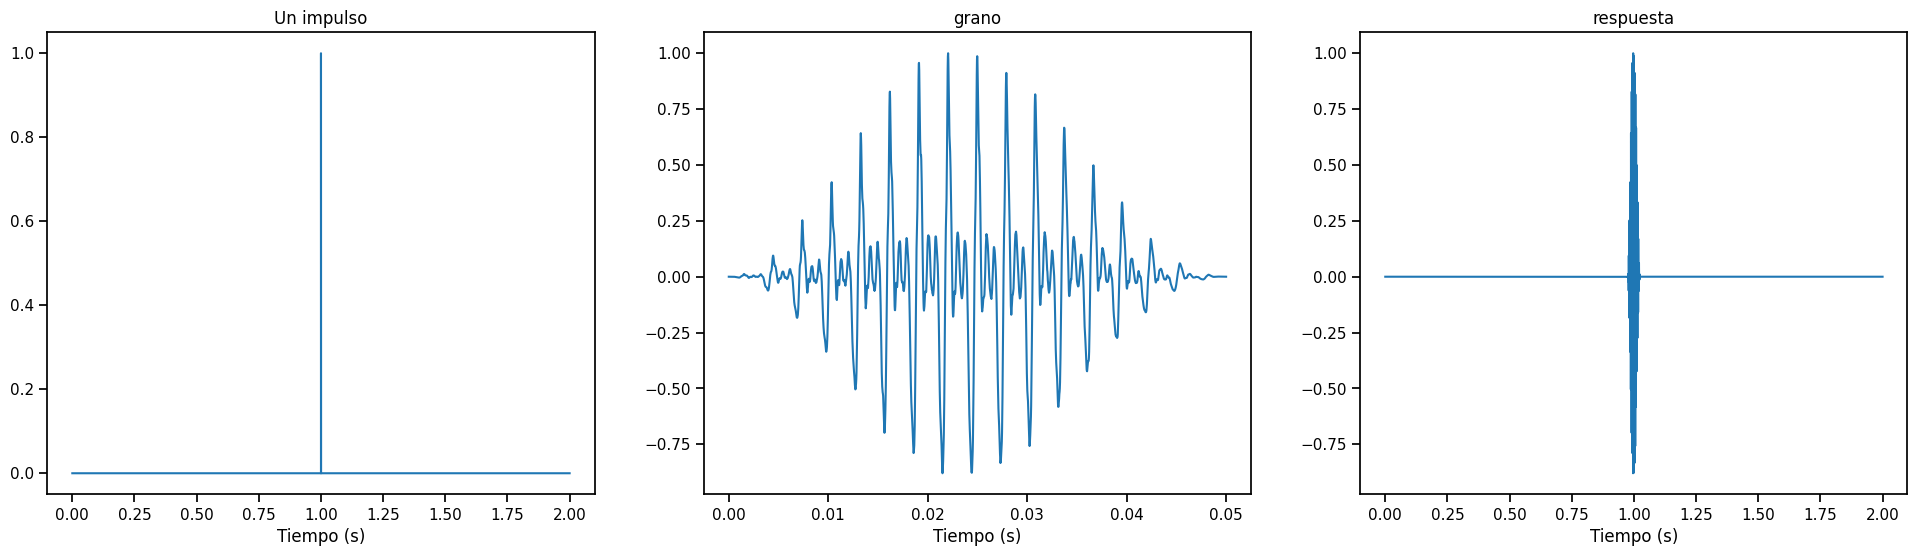

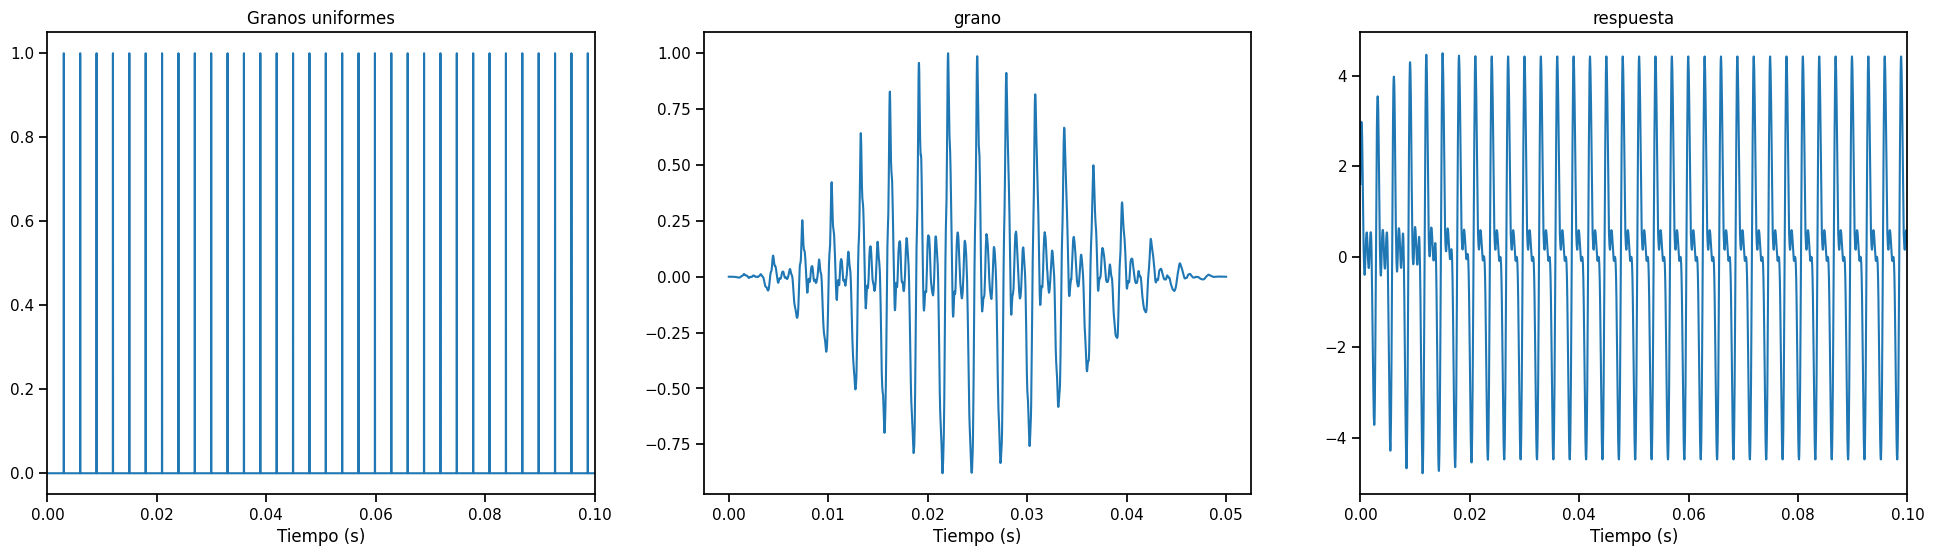

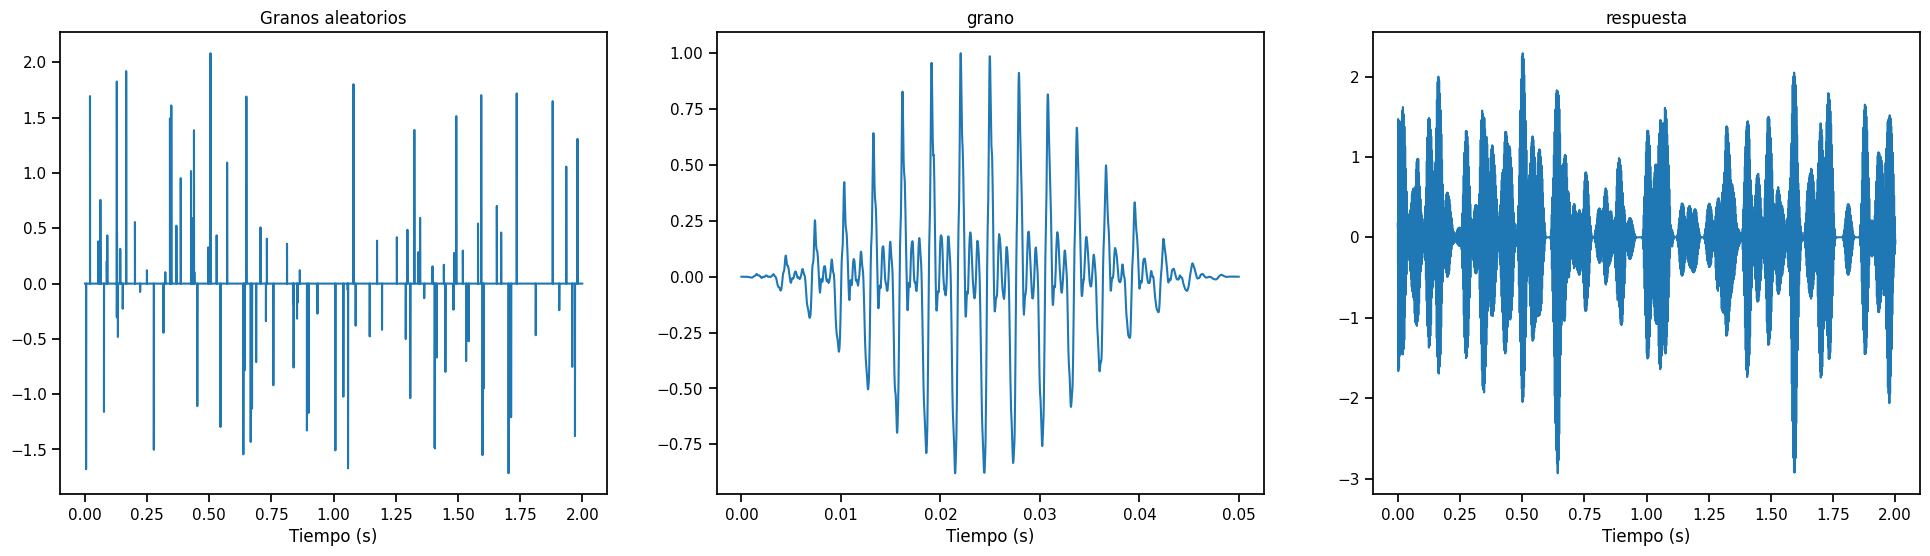

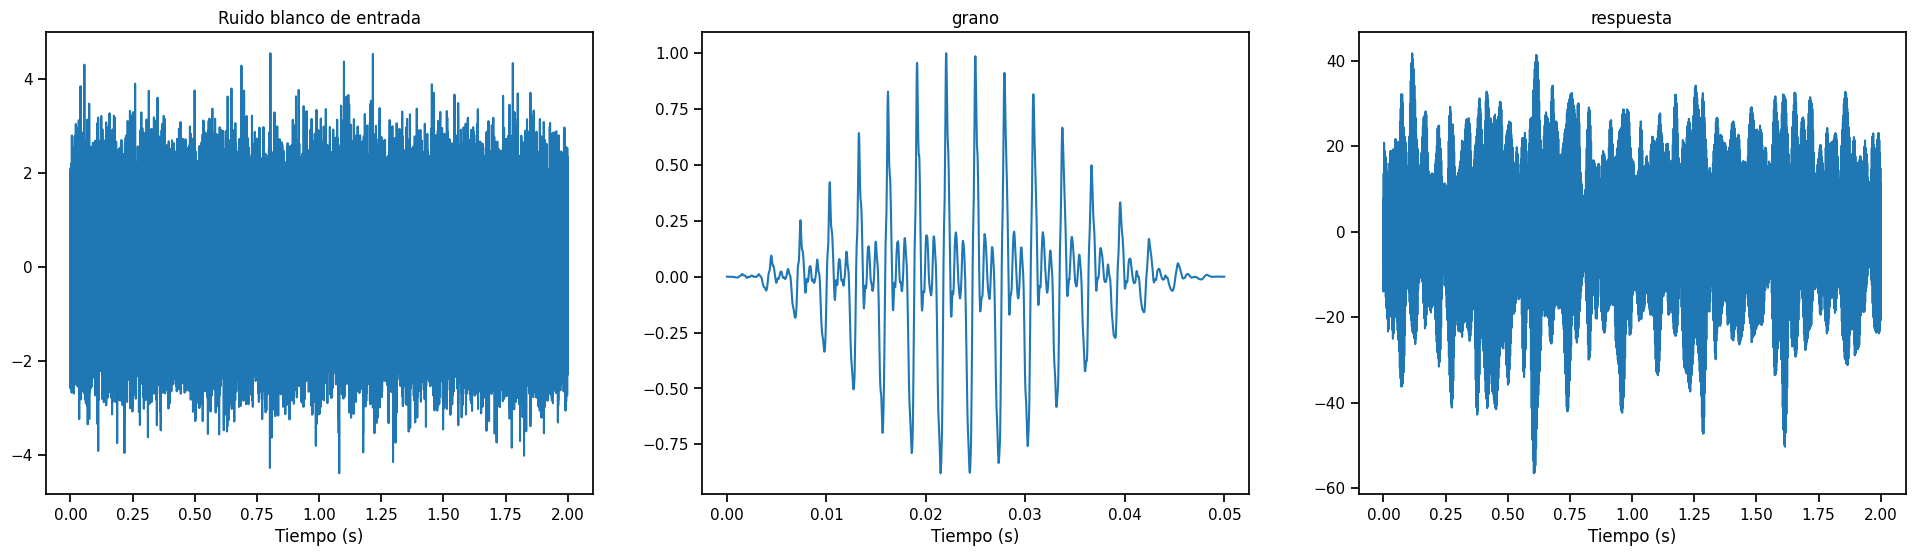

In [ ]:
sr = 44100
dur = 2.0
t = np.arange(int(dur*sr))/sr
x = np.zeros(len(t))

# uno solo
x[x.size//2] = 1 

xs = []
xs.append(("Un impulso",x.copy()))

# granos uniformes

# densidad de granos por segundo
f0 = 332
step = int(sr/f0)

x = np.zeros(len(t))
x[step::step] = 1

xs.append(("Granos uniformes", x.copy()))

# granos aleatorios en tiempo y amplitud
x = np.zeros(len(t))
d = 50 # densidad de granos por segundo
N = int(dur*d)
idx = np.random.randint(0,len(t),N)
x[idx] = np.random.randn(N)

xs.append(("Granos aleatorios", x.copy()))

x = np.random.randn(len(t))

xs.append(("Ruido blanco de entrada", x.copy()))

t_grano = np.arange(len(grano))/sr

for title, x in xs:

    y = np.convolve(x, grano,'same')

    plt.figure(figsize=(24,6))
    plt.subplot(1,3,1)
    plt.plot(t,x)
    plt.xlabel("Tiempo (s)")
    if title == "Granos uniformes":
        plt.xlim(0,0.1)

    plt.title(title)

    plt.subplot(1,3,2)
    plt.plot(t_grano, grano)
    plt.title("grano")
    plt.xlabel("Tiempo (s)")

    plt.subplot(1,3,3)
    plt.plot(t,y)
    plt.xlabel("Tiempo (s)")
    plt.title("respuesta");
    if title == "Granos uniformes":
        plt.xlim(0,0.1)
    display(Audio(y,rate=sr))
    plt.show()

## Convolución con sistemas sensillos

Convolucionamos un impulso con un sistema LTI simple repetidas veces para ver cómo evoluciona la señal de salida.

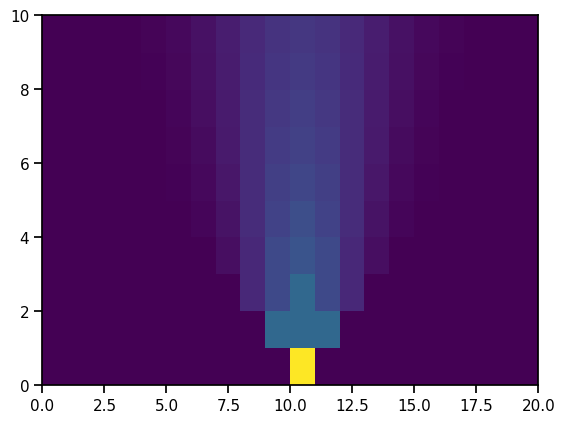

In [ ]:
sr = 20
dur = 1.0
t = np.arange(int(dur*sr))/sr - dur/2
x = np.zeros(t.shape)
x[t==0] = 1

h = np.array([1,1,1])/3
xs= []
for i in range(10):
    xs.append(x)
    x = np.convolve(x,h,'same')   
    
plt.pcolor(xs)
plt.show();

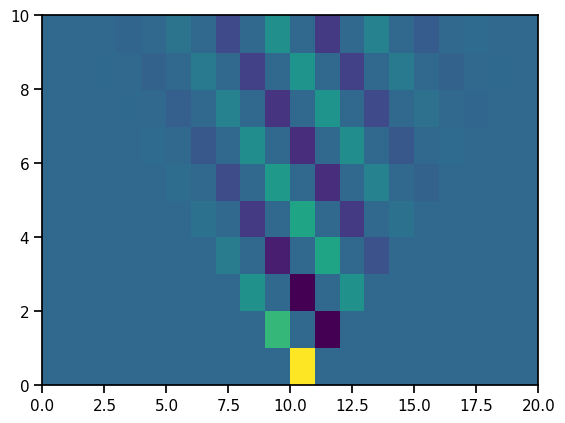

In [ ]:
sr = 20
dur = 1.0
t = np.arange(int(dur*sr))/sr - dur/2
x = np.zeros(t.shape)
x[t==0] = 1

h = np.array([1,0,-1])/2

xs= []
for i in range(10):
    xs.append(x)
    x = np.convolve(x,h,'same')   
    
plt.pcolor(xs)
plt.show();

## Correlación cruzada

Contamos con dos micrófonos registrando un mismo evento sonoro a distintas distancias de la fuente, lo que va generar que el sonido no quede sincronizado entre las señales de cada micrófono. Nos interesa poder calcular el retardo que hay entre los micrófonos para poder alinear ambas grabaciones en el tiempo. Sinteticemos dos respuestas impulso de una sala con un retraso y calculemoslo a partir de las señales.

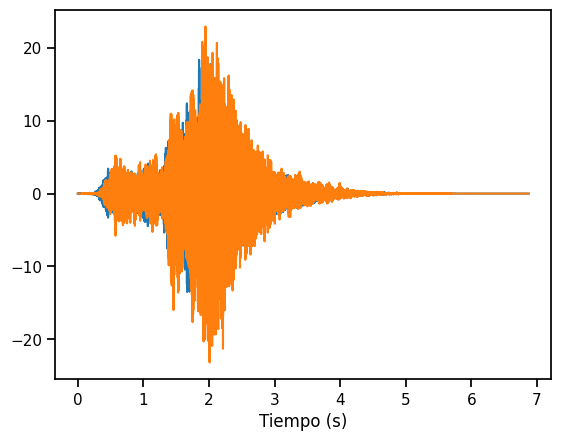

In [ ]:
s, sr = librosa.load('../../assets/singing.wav',sr=44100)
def ir_synth(t_ir, direct_amp = 0.5, delay= 0, sigma=0.001, Am=1, tau=0.35, sr = 44100):
    # ruido
    noise = np.random.normal(0,1,t_ir.size)
    # envolvente
    envelope = Am*np.exp(-t_ir/tau)

    # modulación y piso de ruido
    ir_synth = sigma*np.random.normal(0,1,t_ir.size)
    if delay > 0:
        ir_synth[int(delay*sr):] += (envelope * noise)[:-int(delay*sr)]
    else:
        ir_synth += (envelope * noise) 
    ir_synth[int(t_ir.size//2)] += direct_amp
    ir_synth = ir_synth / np.max(np.abs(ir_synth))
    return ir_synth

t_ir = np.arange(0,int(2*sr))/sr

# probar variando este valor
delay = 0.05

mic1 = np.convolve(s, ir_synth(t_ir, delay=0.0))
mic2 = np.convolve(s, ir_synth(t_ir, delay=delay))
t = np.arange(len(mic1))/sr

plt.plot(t,mic1)
plt.plot(t,mic2)
plt.xlabel("Tiempo (s)")

display(Audio(np.c_[mic1,mic2].T,rate=sr))

plt.show()

Utilizamos la función `numpy.correlate` para calcular la correlación cruzada entre dos señales.

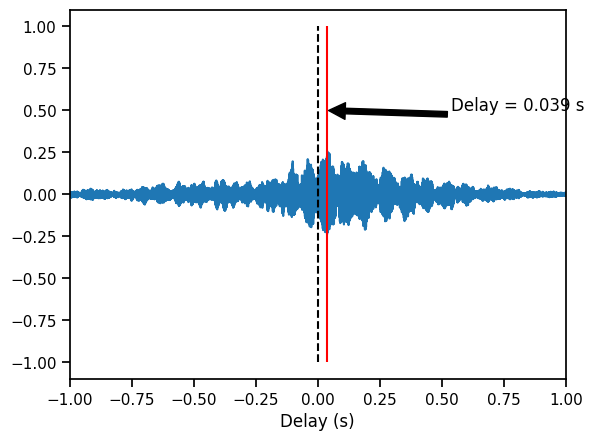

Delay:  0.03882086167800453


In [ ]:
correlation = np.correlate(mic2, mic1, mode='full')
# normalizamos
correlation = correlation/np.sqrt(np.sum(mic2**2))/np.sqrt(np.sum(mic1**2))

delay = np.argmax(correlation) - int(len(correlation)/2)
t = np.arange(len(correlation))/sr-len(correlation)/2/sr

plt.plot(t, correlation)
plt.xlabel('Delay (s)')
plt.vlines(0, -1, 1, 'k', linestyles='--')
plt.vlines(delay/sr, -1, 1, 'r')
plt.annotate(f'Delay = {delay/sr:.3f} s', (delay/sr, 0.5), (delay/sr+0.4, 0.5),
             arrowprops=dict(facecolor='black', shrink=0.01))
plt.xlim(-1,1)
plt.show()
print("Delay: ", delay/sr)

## Auto-Correlación 

La autocorrelación de una señal nos da una medida de la comparación de la señal consigo misma desplazada en el tiempo, lo cual puede ser de utilidad cuando trabajamos señales periódicas. Calculemos el tempo de una pista de bateria, normalmente medido en beats por minutos, o BPM. 

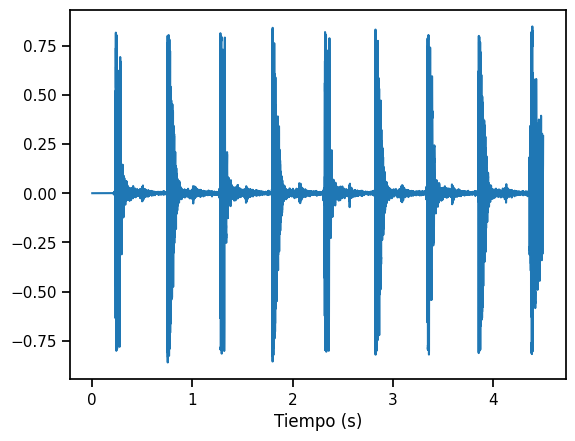

In [ ]:
audio, sr = sf.read("../../assets/bj.wav")
t = np.arange(len(audio))/sr

plt.plot(t, audio)
plt.xlabel("Tiempo (s)")
display(Audio(audio, rate=sr))
plt.show()

Podemos calcular la autocorrelación de la señal directamente pero el resultado es más limpio si lo hacemos sobre la potencia de la señal, es decir, valores solo positivos.

Tempo estimado: 115.8 +/- 3.4 BPMs


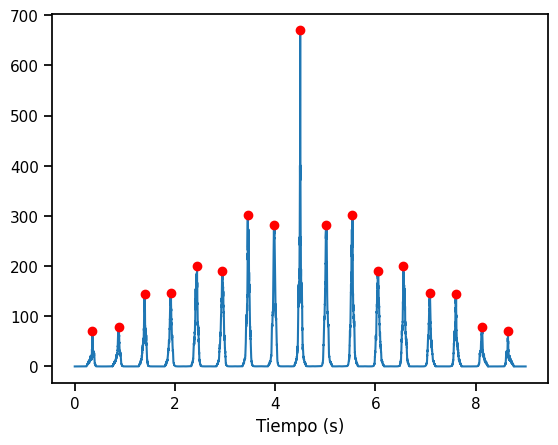

In [ ]:
power = audio**2
acorr = np.correlate(power, power, mode='full')
# normalizamos
acorr = acorr/np.sum(power**2)

t = np.arange(len(acorr))/sr
plt.plot(t, acorr)
plt.xlabel("Tiempo (s)")

# Para detectar los picos utilizamos una función de librosa
pmax = int(44100/10)
peaks = librosa.util.peak_pick(x=acorr, pre_max=pmax, post_max=pmax, pre_avg=1, post_avg=1, delta=0, wait=1)
plt.plot(t[peaks], acorr[peaks], 'ro');

times_between_onsets = np.diff(peaks)/sr
print(f"Tempo estimado: {np.mean(60/times_between_onsets):0.1f} +/- {2*np.std(60/times_between_onsets):0.1f} BPMs")